**Dataset Info**

- Paper: CICIoT2023: A Real-Time Dataset and Benchmark for Large-Scale Attacks in IoT Environment
- Published in: MDPI Sensors 2023
- Date: 26 June 2023
- Links: 
    - https://www.mdpi.com/1424-8220/23/13/5941
    - https://www.unb.ca/cic/datasets/iotdataset-2023.html

In [8]:
import json
from pathlib import Path

import pandas as pd

path = Path('/Users/S4160163/Documents/Projects/RAG Paper/data/cic-iot/')
csv_files = sorted(path.rglob('*.csv'))
if not csv_files:
    raise FileNotFoundError(f'No CSV files found under {path}')

dfs = []
for file_name in csv_files:
    frame = pd.read_csv(file_name)
    # frame['label'] = file_name.parent.name.replace('_Final', '')
    dfs.append(frame)

df = pd.concat(dfs, ignore_index=True)

In [9]:
print("No of Featueres: ", len(df.columns))
print("Features: ", df.columns)

No of Featueres:  44
Features:  Index(['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate',
       'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number',
       'rst_flag_number', 'psh_flag_number', 'ack_flag_number',
       'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count',
       'fin_count', 'urg_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'SSH',
       'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC', 'Tot sum', 'Min',
       'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius',
       'Covariance', 'Variance', 'Weight', 'label'],
      dtype='object')


In [10]:
# Print 1st record as a pretty json along with column names
print("1st record: ", json.dumps(df.iloc[0].to_dict(), indent=4))

1st record:  {
    "flow_duration": 56.446859788894656,
    "Header_Length": 208195.9,
    "Protocol Type": 3.6,
    "Duration": 52.5,
    "Rate": 23.883651844598297,
    "Srate": 23.883651844598297,
    "Drate": 0.0,
    "fin_flag_number": 0.0,
    "syn_flag_number": 0.0,
    "rst_flag_number": 0.0,
    "psh_flag_number": 0.0,
    "ack_flag_number": 1.0,
    "ece_flag_number": 0.0,
    "cwr_flag_number": 0.0,
    "ack_count": 0.0,
    "syn_count": 0.2,
    "fin_count": 0.0,
    "urg_count": 403.3,
    "rst_count": 905.4,
    "HTTP": 0.0,
    "HTTPS": 0.0,
    "DNS": 0.0,
    "SSH": 0.0,
    "TCP": 1.0,
    "UDP": 0.0,
    "DHCP": 0.0,
    "ARP": 0.0,
    "ICMP": 0.0,
    "IPv": 1.0,
    "LLC": 1.0,
    "Tot sum": 421.2,
    "Min": 55.2,
    "Max": 129.0,
    "AVG": 73.71214285714285,
    "Std": 26.91078645170317,
    "Tot size": 80.4,
    "IAT": 0.0220431089401245,
    "Number": 5.5,
    "Magnitue": 12.121156303778417,
    "Radius": 38.05759917412477,
    "Covariance": 965.96909693877

In [11]:
# Print describe of the dataset in pretty json
print(json.dumps(df.describe().to_dict(), indent=4))

{
    "flow_duration": {
        "count": 1000.0,
        "mean": 22.91664564966917,
        "std": 49.4647549079549,
        "min": 0.0,
        "25%": 0.0,
        "50%": 3.0338750994205474,
        "75%": 28.1957886993885,
        "max": 558.2071863412857
    },
    "Header_Length": {
        "count": 1000.0,
        "mean": 494691.75015777774,
        "std": 1041345.4377508496,
        "min": 0.0,
        "25%": 54.0,
        "50%": 22934.9,
        "75%": 505265.875,
        "max": 8093119.8
    },
    "Protocol Type": {
        "count": 1000.0,
        "mean": 8.475734444444445,
        "std": 6.990606095844983,
        "min": 0.96,
        "25%": 6.0,
        "50%": 6.0,
        "75%": 8.4,
        "max": 47.0
    },
    "Duration": {
        "count": 1000.0,
        "mean": 89.21676444444445,
        "std": 44.51065884896301,
        "min": 36.9,
        "25%": 64.0,
        "50%": 64.0,
        "75%": 96.69999999999999,
        "max": 247.0
    },
    "Rate": {
        "count"

In [12]:
# Print no of classes and their names
print("No of classes: ", len(df['label'].unique()))
print(df['label'].unique())

No of classes:  23
['BenignTraffic' 'DDoS-UDP_Flood' 'DDoS-RSTFINFlood' 'DoS-SYN_Flood'
 'Backdoor_Malware' 'DDoS-SYN_Flood' 'DDoS-PSHACK_Flood'
 'DDoS-SynonymousIP_Flood' 'DoS-TCP_Flood' 'DDoS-ICMP_Flood'
 'DDoS-TCP_Flood' 'DoS-UDP_Flood' 'Mirai-greip_flood'
 'DDoS-UDP_Fragmentation' 'DDoS-ACK_Fragmentation'
 'DDoS-ICMP_Fragmentation' 'Mirai-greeth_flood' 'DoS-HTTP_Flood'
 'MITM-ArpSpoofing' 'Mirai-udpplain' 'DDoS-SlowLoris'
 'Recon-HostDiscovery' 'DNS_Spoofing']


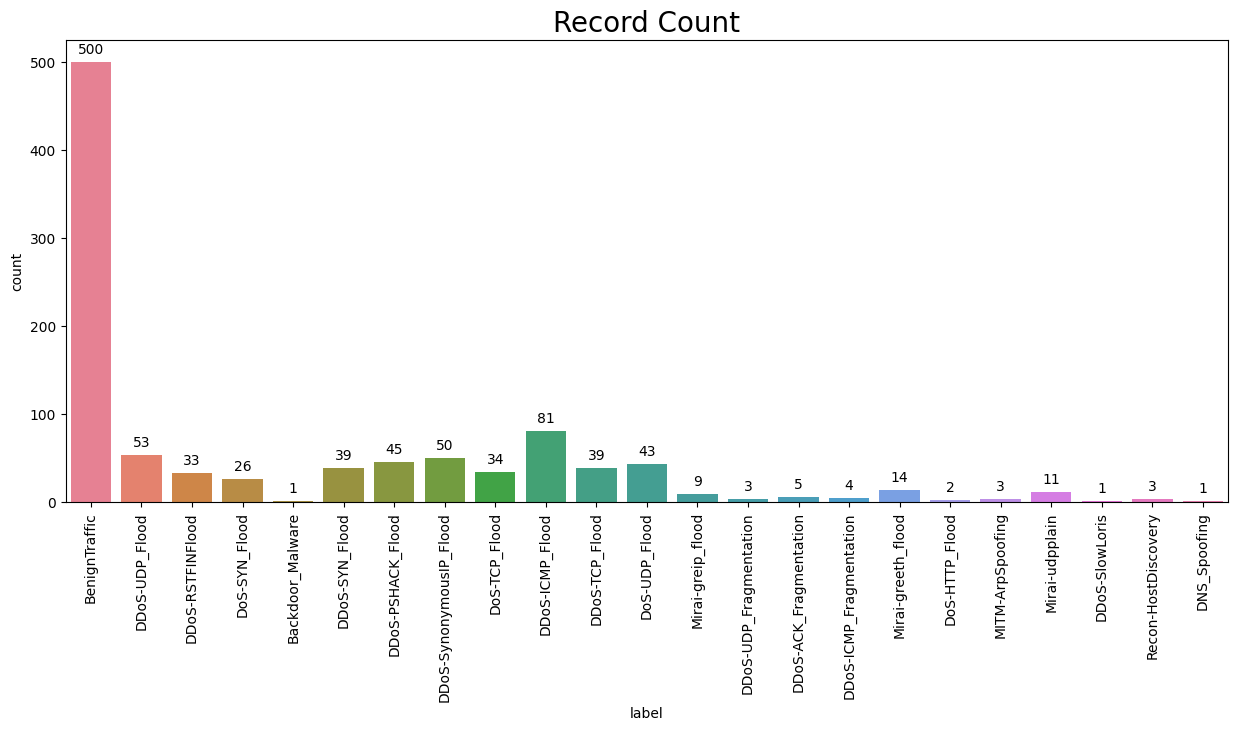

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 6))
plt.xticks(rotation=90)
s = sns.countplot(data=df, x='label', hue='label')
for p in s.patches:
    s.annotate(format(p.get_height(), '.0f'), 
               (p.get_x() + p.get_width() / 2., p.get_height()), 
               ha = 'center', va = 'center', 
               xytext = (0, 9), 
               textcoords = 'offset points')
plt.title('Record Count', fontsize=20)

plt.show()

In [14]:
# Remove duplicate rows
df_no_duplicates = df.drop_duplicates()

# Print length of dataset after removing duplicates
print("Length of dataset before removing duplicates: ", len(df))
print("Length of dataset after removing duplicates: ", len(df_no_duplicates))

Length of dataset before removing duplicates:  1000
Length of dataset after removing duplicates:  1000
